# 📊 Telco Customer Churn - Exploratory Analysis

**Purpose:** Understand customer behaviour, identify churn drivers, and surface actionable business insights.  
**Input:** `data/processed/cleaned_telco.csv` → loaded into SQLite for SQL-based analysis  

### Table of Contents
1. [Setup & Data Load](#1)
2. [Dataset Overview](#2)
3. [Churn Rate Analysis](#3)
4. [Customer Segmentation by Tenure](#4)
5. [Revenue Analysis & Top Customers](#5)
6. [Churn Drivers - Multivariate View](#6)
7. [Service Adoption & Churn Risk](#7)
8. [Contract & Payment Method Analysis](#8)
9. [Anomaly Detection (IQR Method)](#9)
10. [Summary & Recommendations](#10)

<a id='1'></a>
## 1. Setup & Data Load

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
})
PALETTE = {'No': '#4C9BE8', 'Yes': '#E8614C'}
ACCENT  = '#E8614C'

# ── Database ─────────────────────────────────────────────────────────────────
DB_PATH  = '../database.db'
CSV_PATH = '../data/processed/cleaned_telco.csv'

conn = sqlite3.connect(DB_PATH)
df   = pd.read_csv(CSV_PATH)
df.to_sql('telco', conn, if_exists='replace', index=False)

def q(sql):
    """Run a SQL query and return a DataFrame."""
    return pd.read_sql(sql, conn)

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns into SQLite table `telco`.')

Loaded 7,032 rows × 26 columns into SQLite table `telco`.


<a id='2'></a>
## 2. Dataset Overview

In [4]:
overview = q("""
    SELECT
        COUNT(*)                            AS total_customers,
        SUM(churn_binary)                   AS churned,
        ROUND(AVG(churn_binary)*100, 1)     AS churn_rate_pct,
        ROUND(AVG(monthlycharges), 2)       AS avg_monthly_charge,
        ROUND(AVG(totalcharges), 2)         AS avg_total_charge,
        ROUND(AVG(tenure), 1)               AS avg_tenure_months,
        ROUND(AVG(num_services), 2)         AS avg_services
    FROM telco
""")
overview.T.rename(columns={0: 'value'})

,value
total_customers,7032.00
churned,1869.00
churn_rate_pct,26.60
avg_monthly_charge,64.80
avg_total_charge,2283.30
avg_tenure_months,32.40
avg_services,2.04


<a id='3'></a>
## 3. Churn Rate Analysis

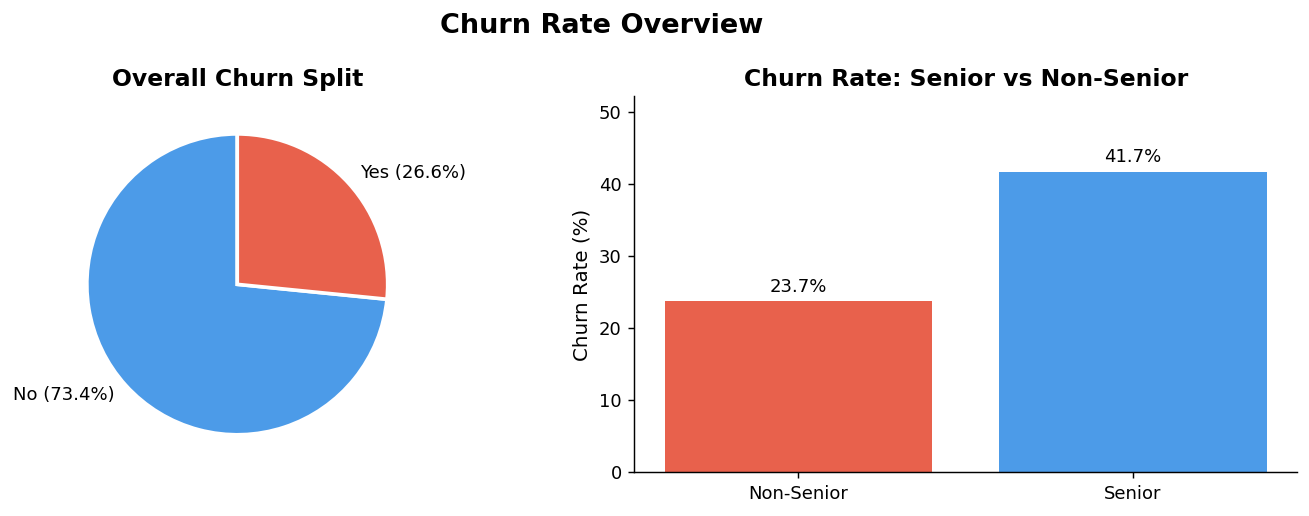

churn  customers  pct
   No       5163 73.4
  Yes       1869 26.6


In [5]:
churn_counts = q("""
    SELECT churn, COUNT(*) AS customers,
           ROUND(COUNT(*)*100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM telco GROUP BY churn
""")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie chart
axes[0].pie(
    churn_counts['customers'],
    labels=[f"{r} ({p}%)" for r, p in zip(churn_counts['churn'], churn_counts['pct'])],
    colors=[PALETTE[v] for v in churn_counts['churn']],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Churn Split')

# Churn rate by senior citizen status
senior = q("""
    SELECT
        CASE WHEN seniorcitizen = 1 THEN 'Senior' ELSE 'Non-Senior' END AS segment,
        ROUND(AVG(churn_binary)*100, 1) AS churn_rate
    FROM telco GROUP BY seniorcitizen
""")
bars = axes[1].bar(senior['segment'], senior['churn_rate'],
                   color=[PALETTE['Yes'], PALETTE['No']])
axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1].set_title('Churn Rate: Senior vs Non-Senior')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, senior['churn_rate'].max() * 1.25)

fig.suptitle('Churn Rate Overview', fontweight='bold')
plt.tight_layout()
plt.show()

print(churn_counts.to_string(index=False))

<a id='4'></a>
## 4. Customer Segmentation by Tenure

Customers are grouped into four tenure buckets and compared on revenue and churn.

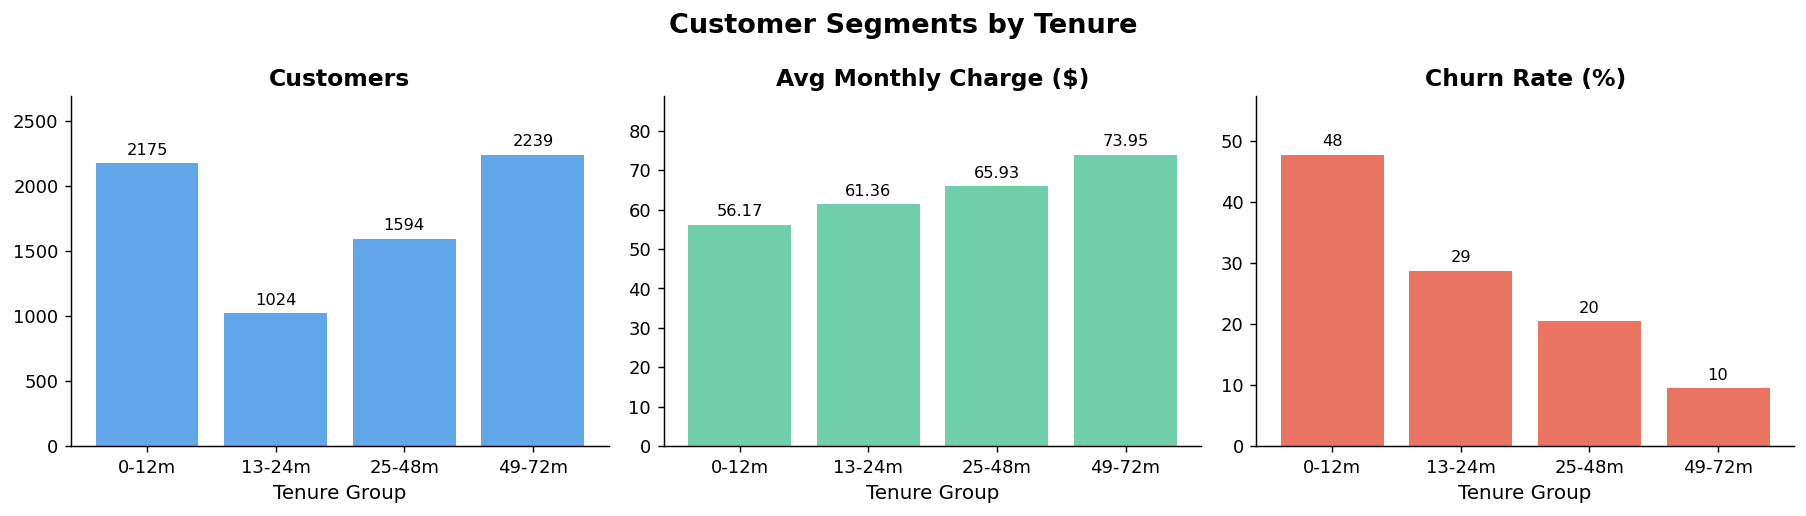

tenure_group  customers  avg_monthly_charge  avg_total_charge  churn_rate_pct
       0-12m       2175               56.17            276.62            47.7
      13-24m       1024               61.36           1126.26            28.7
      25-48m       1594               65.93           2390.45            20.4
      49-72m       2239               73.95           4685.51             9.5


In [6]:
segments = q("""
    SELECT
        tenure_group,
        COUNT(*)                                AS customers,
        ROUND(AVG(monthlycharges), 2)           AS avg_monthly_charge,
        ROUND(AVG(totalcharges), 2)             AS avg_total_charge,
        ROUND(AVG(churn_binary)*100, 1)         AS churn_rate_pct
    FROM telco
    GROUP BY tenure_group
    ORDER BY tenure_group
""")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label, color in zip(
    axes,
    ['customers', 'avg_monthly_charge', 'churn_rate_pct'],
    ['Customers', 'Avg Monthly Charge ($)', 'Churn Rate (%)'],
    ['#4C9BE8', '#5CC8A0', '#E8614C']
):
    bars = ax.bar(segments['tenure_group'], segments[col], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.0f' if col != 'avg_monthly_charge' else '%.2f',
                 padding=3, fontsize=9)
    ax.set_title(label)
    ax.set_xlabel('Tenure Group')
    ax.set_ylim(0, segments[col].max() * 1.2)

fig.suptitle('Customer Segments by Tenure', fontweight='bold')
plt.tight_layout()
plt.show()

print(segments.to_string(index=False))

### Insights
- New customers (0-12 months) have the **highest churn rate** - early engagement programmes are critical.
- Long-term customers (49-72 months) generate the highest average total charges but are relatively stable.
- Monthly charges are **surprisingly consistent across segments**, meaning tenure itself, not pricing, drives total revenue.

---

<a id='5'></a>
## 5. Revenue Analysis & Top Customers

In [7]:
top10 = q("""
    SELECT
        customerid,
        tenure,
        monthlycharges,
        totalcharges,
        contract,
        churn,
        DENSE_RANK() OVER (ORDER BY totalcharges DESC) AS revenue_rank
    FROM telco
    LIMIT 10
""")
print('Top 10 Customers by Total Revenue:')
top10

Top 10 Customers by Total Revenue:


,customerid,tenure,monthlycharges,totalcharges,contract,churn,revenue_rank
0,2889-FPWRM,72,117.80,8684.80,One year,Yes,1
1,7569-NMZYQ,72,118.75,8672.45,Two year,No,2
2,9739-JLPQJ,72,117.50,8670.10,Two year,No,3
3,9788-HNGUT,72,116.95,8594.40,Two year,No,4
4,8879-XUAHX,71,116.25,8564.75,Two year,No,5
5,9924-JPRMC,72,118.20,8547.15,Two year,No,6
6,0675-NCDYU,72,116.40,8543.25,Two year,No,7
7,6650-BWFRT,72,117.15,8529.50,Two year,No,8
8,0164-APGRB,72,114.90,8496.70,Two year,No,9
9,1488-PBLJN,72,116.85,8477.70,Two year,No,10


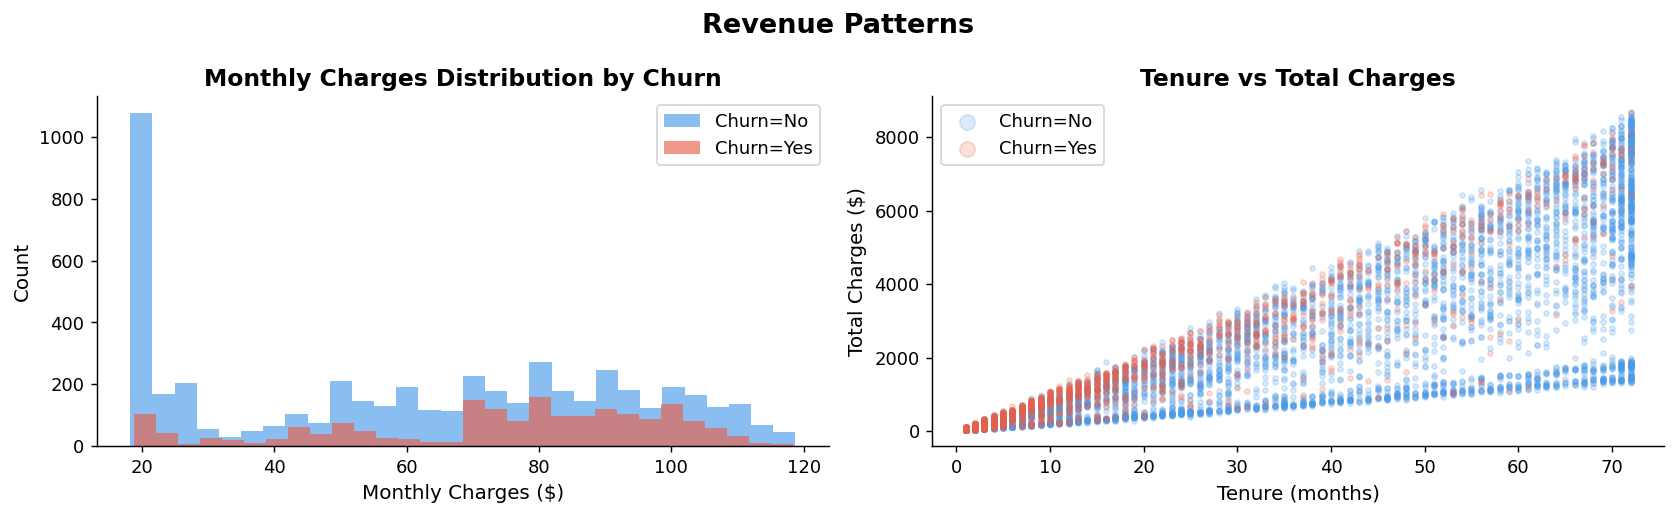

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Monthly charges distribution by churn
for churn_val, color in PALETTE.items():
    subset = df[df['churn'] == churn_val]['monthlycharges']
    axes[0].hist(subset, bins=30, alpha=0.65, color=color, label=f'Churn={churn_val}')
axes[0].set_title('Monthly Charges Distribution by Churn')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Tenure vs total charges, coloured by churn
for churn_val, color in PALETTE.items():
    subset = df[df['churn'] == churn_val]
    axes[1].scatter(subset['tenure'], subset['totalcharges'],
                    alpha=0.2, s=8, color=color, label=f'Churn={churn_val}')
axes[1].set_title('Tenure vs Total Charges')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Total Charges ($)')
axes[1].legend(markerscale=3)

fig.suptitle('Revenue Patterns', fontweight='bold')
plt.tight_layout()
plt.show()

### Insights
- Churned customers cluster at **higher monthly charges** - price sensitivity is a real churn driver.
- Churned customers tend to have **low tenure**, confirming the early-life risk pattern.
- Long-tenure, high-revenue customers rarely churn - retaining them is paramount.

---

<a id='6'></a>
## 6. Churn Drivers - Multivariate View

Which demographic and service features correlate most with churn?

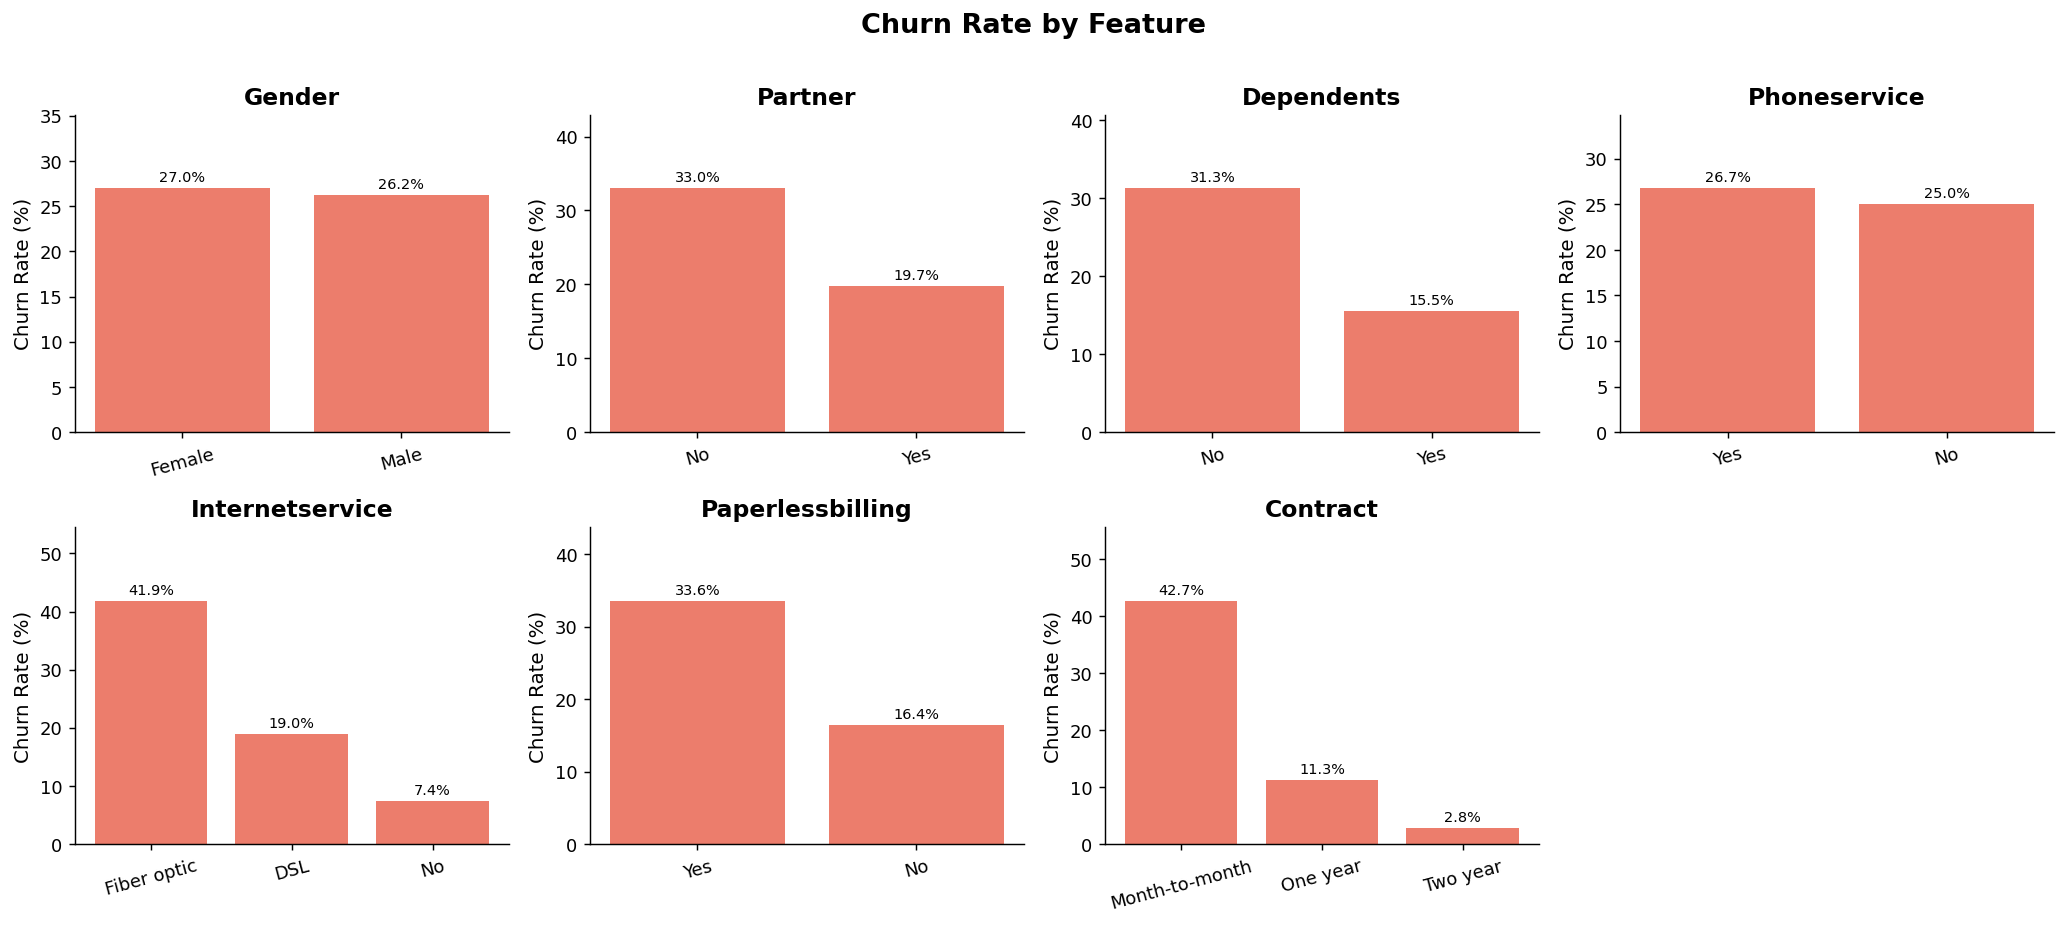

In [9]:
categorical_features = [
    'gender', 'partner', 'dependents', 'phoneservice',
    'internetservice', 'paperlessbilling', 'contract'
]

churn_rates = {}
for feat in categorical_features:
    rates = df.groupby(feat)['churn_binary'].mean().sort_values(ascending=False)
    churn_rates[feat] = rates

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (feat, rates) in enumerate(churn_rates.items()):
    bars = axes[i].bar(rates.index, rates.values * 100, color=ACCENT, alpha=0.82)
    axes[i].bar_label(bars, fmt='%.1f%%', padding=2, fontsize=8)
    axes[i].set_title(feat.capitalize())
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, rates.max() * 130)
    axes[i].tick_params(axis='x', labelrotation=15)

axes[-1].set_visible(False)  # hide unused subplot
fig.suptitle('Churn Rate by Feature', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

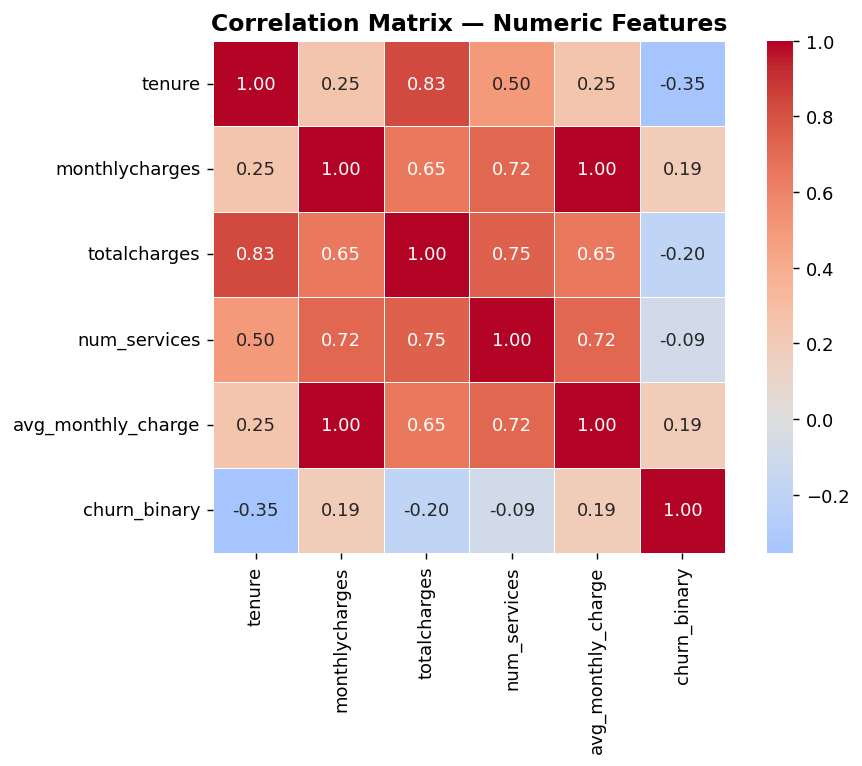

In [10]:
# Correlation heatmap on numeric features
numeric_cols = ['tenure', 'monthlycharges', 'totalcharges',
                'num_services', 'avg_monthly_charge', 'churn_binary']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### Insights
- **Contract type** is the strongest categorical churn predictor - month-to-month customers churn at much higher rates.
- **Fiber optic** internet customers churn more than DSL customers, suggesting service quality or pricing issues.
- **Paperless billing** correlates positively with churn - likely because it correlates with digital-native, price-comparing customers.
- `tenure` has the **strongest negative correlation** with churn: the longer a customer stays, the less likely they are to leave.

---

<a id='7'></a>
## 7. Service Adoption & Churn Risk

Does subscribing to more services reduce churn? And which services protect against churn most?

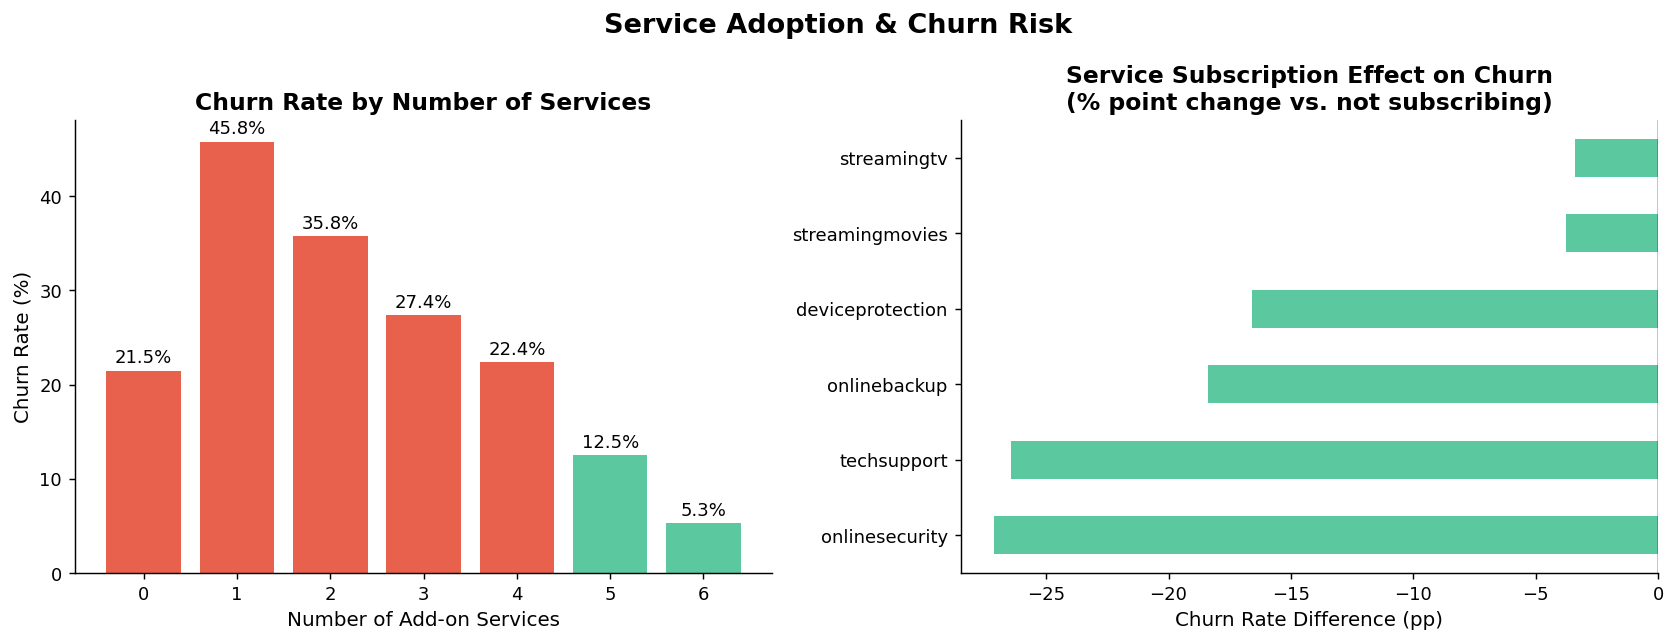

 num_services  customers  churn_rate_pct  avg_monthly_charge
            0       2213            21.5               32.82
            1        966            45.8               65.57
            2       1033            35.8               72.42
            3       1117            27.4               80.13
            4        850            22.4               87.83
            5        569            12.5               92.26
            6        284             5.3               99.37


In [11]:
svc_churn = q("""
    SELECT
        num_services,
        COUNT(*)                             AS customers,
        ROUND(AVG(churn_binary)*100, 1)      AS churn_rate_pct,
        ROUND(AVG(monthlycharges), 2)        AS avg_monthly_charge
    FROM telco
    GROUP BY num_services
    ORDER BY num_services
""")

service_impact = {}
for svc in ['onlinesecurity', 'onlinebackup', 'deviceprotection',
            'techsupport', 'streamingtv', 'streamingmovies']:
    rates = df[df[svc].isin(['Yes','No'])].groupby(svc)['churn_binary'].mean() * 100
    service_impact[svc] = rates.get('Yes', 0) - rates.get('No', 0)

impact_df = pd.Series(service_impact).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate by number of services
ax = axes[0]
color_map = ['#E8614C' if c > 20 else '#5CC8A0' for c in svc_churn['churn_rate_pct']]
bars = ax.bar(svc_churn['num_services'], svc_churn['churn_rate_pct'], color=color_map)
ax.bar_label(bars, fmt='%.1f%%', padding=2)
ax.set_title('Churn Rate by Number of Services')
ax.set_xlabel('Number of Add-on Services')
ax.set_ylabel('Churn Rate (%)')

# Service impact on churn (positive = increases churn, negative = reduces)
ax2 = axes[1]
colors = ['#E8614C' if v > 0 else '#5CC8A0' for v in impact_df]
impact_df.plot(kind='barh', ax=ax2, color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Service Subscription Effect on Churn\n(% point change vs. not subscribing)')
ax2.set_xlabel('Churn Rate Difference (pp)')

fig.suptitle('Service Adoption & Churn Risk', fontweight='bold')
plt.tight_layout()
plt.show()

print(svc_churn.to_string(index=False))

### Insights
- Customers with **more services churn less** - product bundling is a retention tool.
- **Online Security** and **Tech Support** subscriptions show the largest churn-reducing effect.
- **Streaming services** (TV & Movies) show little to no protective effect on churn.

---

<a id='8'></a>
## 8. Contract & Payment Method Analysis

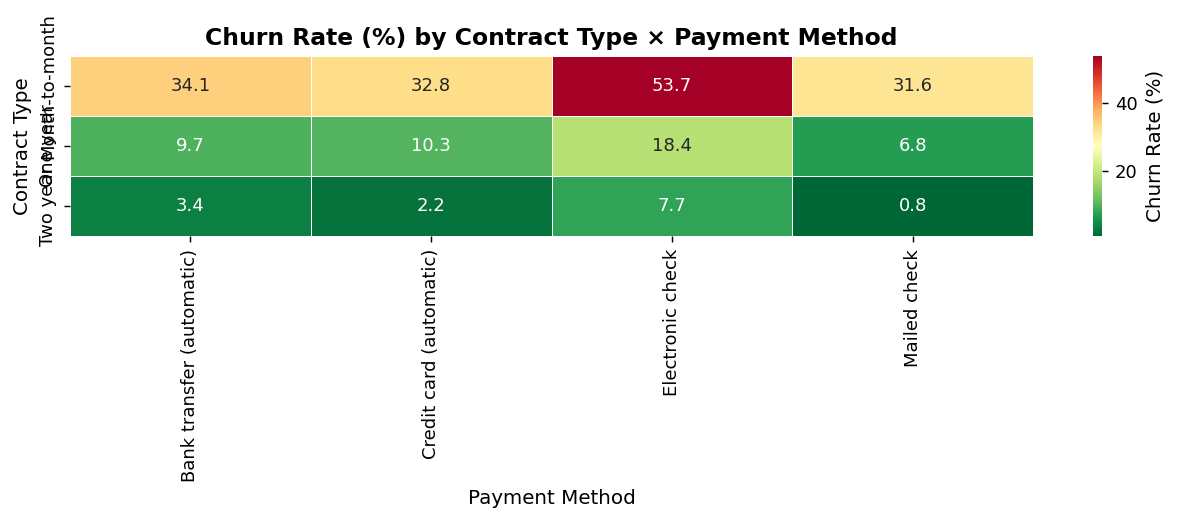

In [12]:
contract_churn = q("""
    SELECT
        contract,
        paymentmethod,
        COUNT(*)                              AS customers,
        ROUND(AVG(churn_binary)*100, 1)       AS churn_rate_pct,
        ROUND(AVG(monthlycharges), 2)         AS avg_monthly
    FROM telco
    GROUP BY contract, paymentmethod
    ORDER BY churn_rate_pct DESC
""")

pivot = contract_churn.pivot_table(
    index='contract', columns='paymentmethod',
    values='churn_rate_pct', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) by Contract Type × Payment Method', fontweight='bold')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Contract Type')
plt.tight_layout()
plt.show()

### Insights
- **Month-to-month + Electronic check** is the highest-risk combination by far.
- **Two-year contract** customers have near-zero churn regardless of payment method.
- Migrating at-risk customers from electronic check to automatic payment may reduce churn.

---

<a id='9'></a>
## 9. Anomaly Detection (IQR Method)

We use the **Interquartile Range (IQR)** method, which is robust to skew and doesn't assume normality.  
Anomalies are defined as values above `Q3 + 1.5 × IQR`.

Q1=35.59  Q3=89.86  IQR=54.27  Upper fence=171.27

Normal customers : 7,032
Anomaly customers: 0 (0.0% of total)


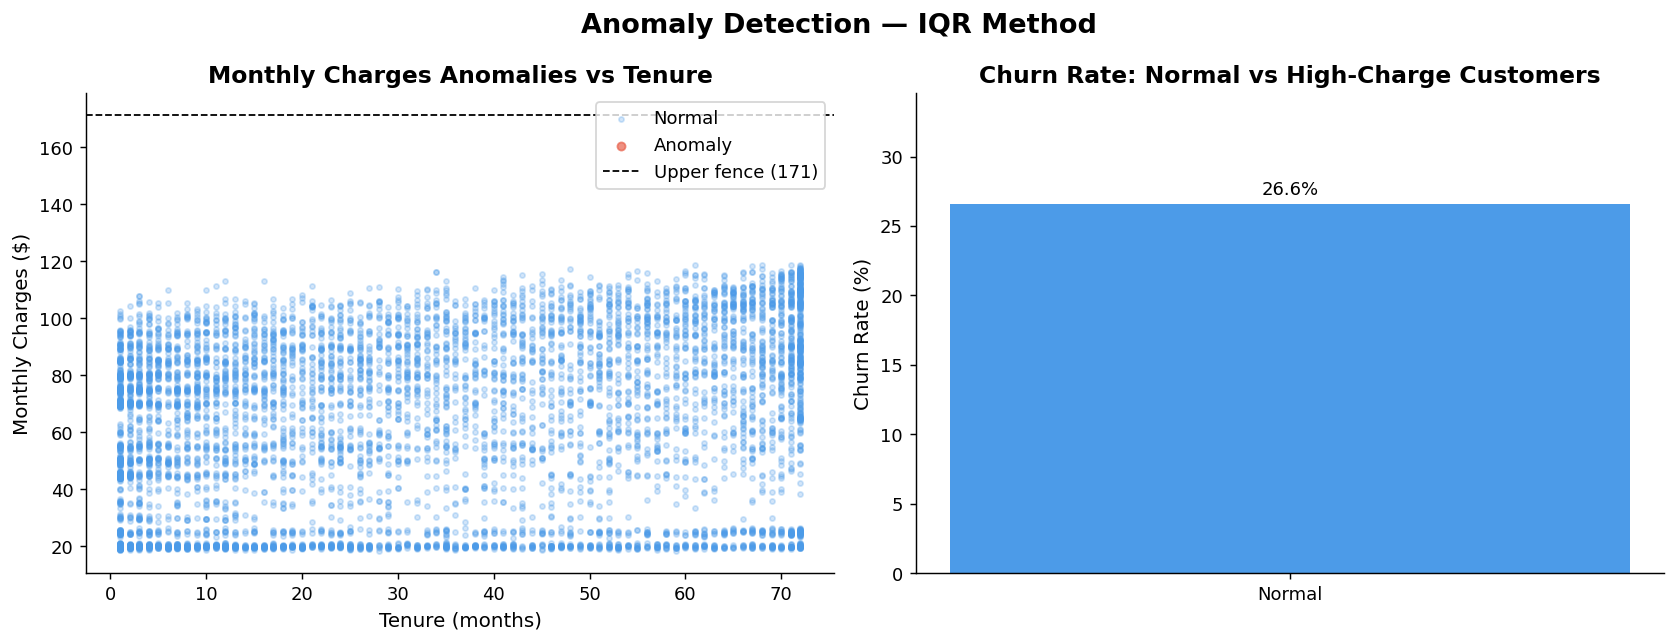

In [14]:
# Percentile computation in pandas (SQLite has no built-in percentile function)
q1 = df['monthlycharges'].quantile(0.25)
q3 = df['monthlycharges'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

print(f'Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}  Upper fence={upper_fence:.2f}')

df_normal  = df[df['monthlycharges'] <= upper_fence]
df_anomaly = df[df['monthlycharges'] >  upper_fence]

print(f'\nNormal customers : {len(df_normal):,}')
print(f'Anomaly customers: {len(df_anomaly):,} ({len(df_anomaly)/len(df):.1%} of total)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: tenure vs monthly charges
axes[0].scatter(df_normal['tenure'],  df_normal['monthlycharges'],
                alpha=0.25, s=8,  color='#4C9BE8', label='Normal')
axes[0].scatter(df_anomaly['tenure'], df_anomaly['monthlycharges'],
                alpha=0.7,  s=20, color=ACCENT,    label='Anomaly')
axes[0].axhline(upper_fence, linestyle='--', color='black', linewidth=1, label=f'Upper fence ({upper_fence:.0f})')
axes[0].set_title('Monthly Charges Anomalies vs Tenure')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].legend()

# Anomaly churn rate vs normal
comparison = pd.DataFrame({
    'Segment': ['Normal', 'Anomaly (High Charge)'],
    'Churn Rate': [
        df_normal['churn_binary'].mean() * 100,
        df_anomaly['churn_binary'].mean() * 100
    ]
})
bars = axes[1].bar(comparison['Segment'], comparison['Churn Rate'],
                   color=['#4C9BE8', ACCENT])
axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1].set_title('Churn Rate: Normal vs High-Charge Customers')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, comparison['Churn Rate'].max() * 1.3)

fig.suptitle('Anomaly Detection — IQR Method', fontweight='bold')
plt.tight_layout()
plt.show()

### Insights
- High-charge customers (above the IQR fence) are identifiable across all tenure levels - this isn't just a long-tenure premium segment.
- Comparing their churn rate to the broader base reveals whether high charges alone drive churn.

---

<a id='10'></a>
## 10. Summary & Recommendations

| # | Finding | Recommended Action |
|---|---|---|
| 1 | Month-to-month customers churn at ~42% | Offer incentives to upgrade to 1-year contracts |
| 2 | Electronic check users are highest-risk | Promote autopay migration with a discount |
| 3 | New customers (0-12 months) churn most | Launch 90-day onboarding & engagement programme |
| 4 | Online Security & Tech Support reduce churn | Bundle protective services into base plans |
| 5 | Fiber optic churn exceeds DSL | Investigate service quality / pricing perception |
| 6 | More services → lower churn | Upsell bundles early in the customer lifecycle |
